In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

#R squared 
from sklearn.metrics import r2_score as R2

#features engineering
from sklearn.preprocessing import StandardScaler

#Grid search CV
from sklearn.model_selection import GridSearchCV

sns.set_theme() 

In [3]:
#concrete compressive strength dataset fro kaggle
file_name = "ccs.csv"

data = pd.read_csv(file_name)

df = pd.DataFrame(data)

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [4]:
# Dataset stattistics info
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


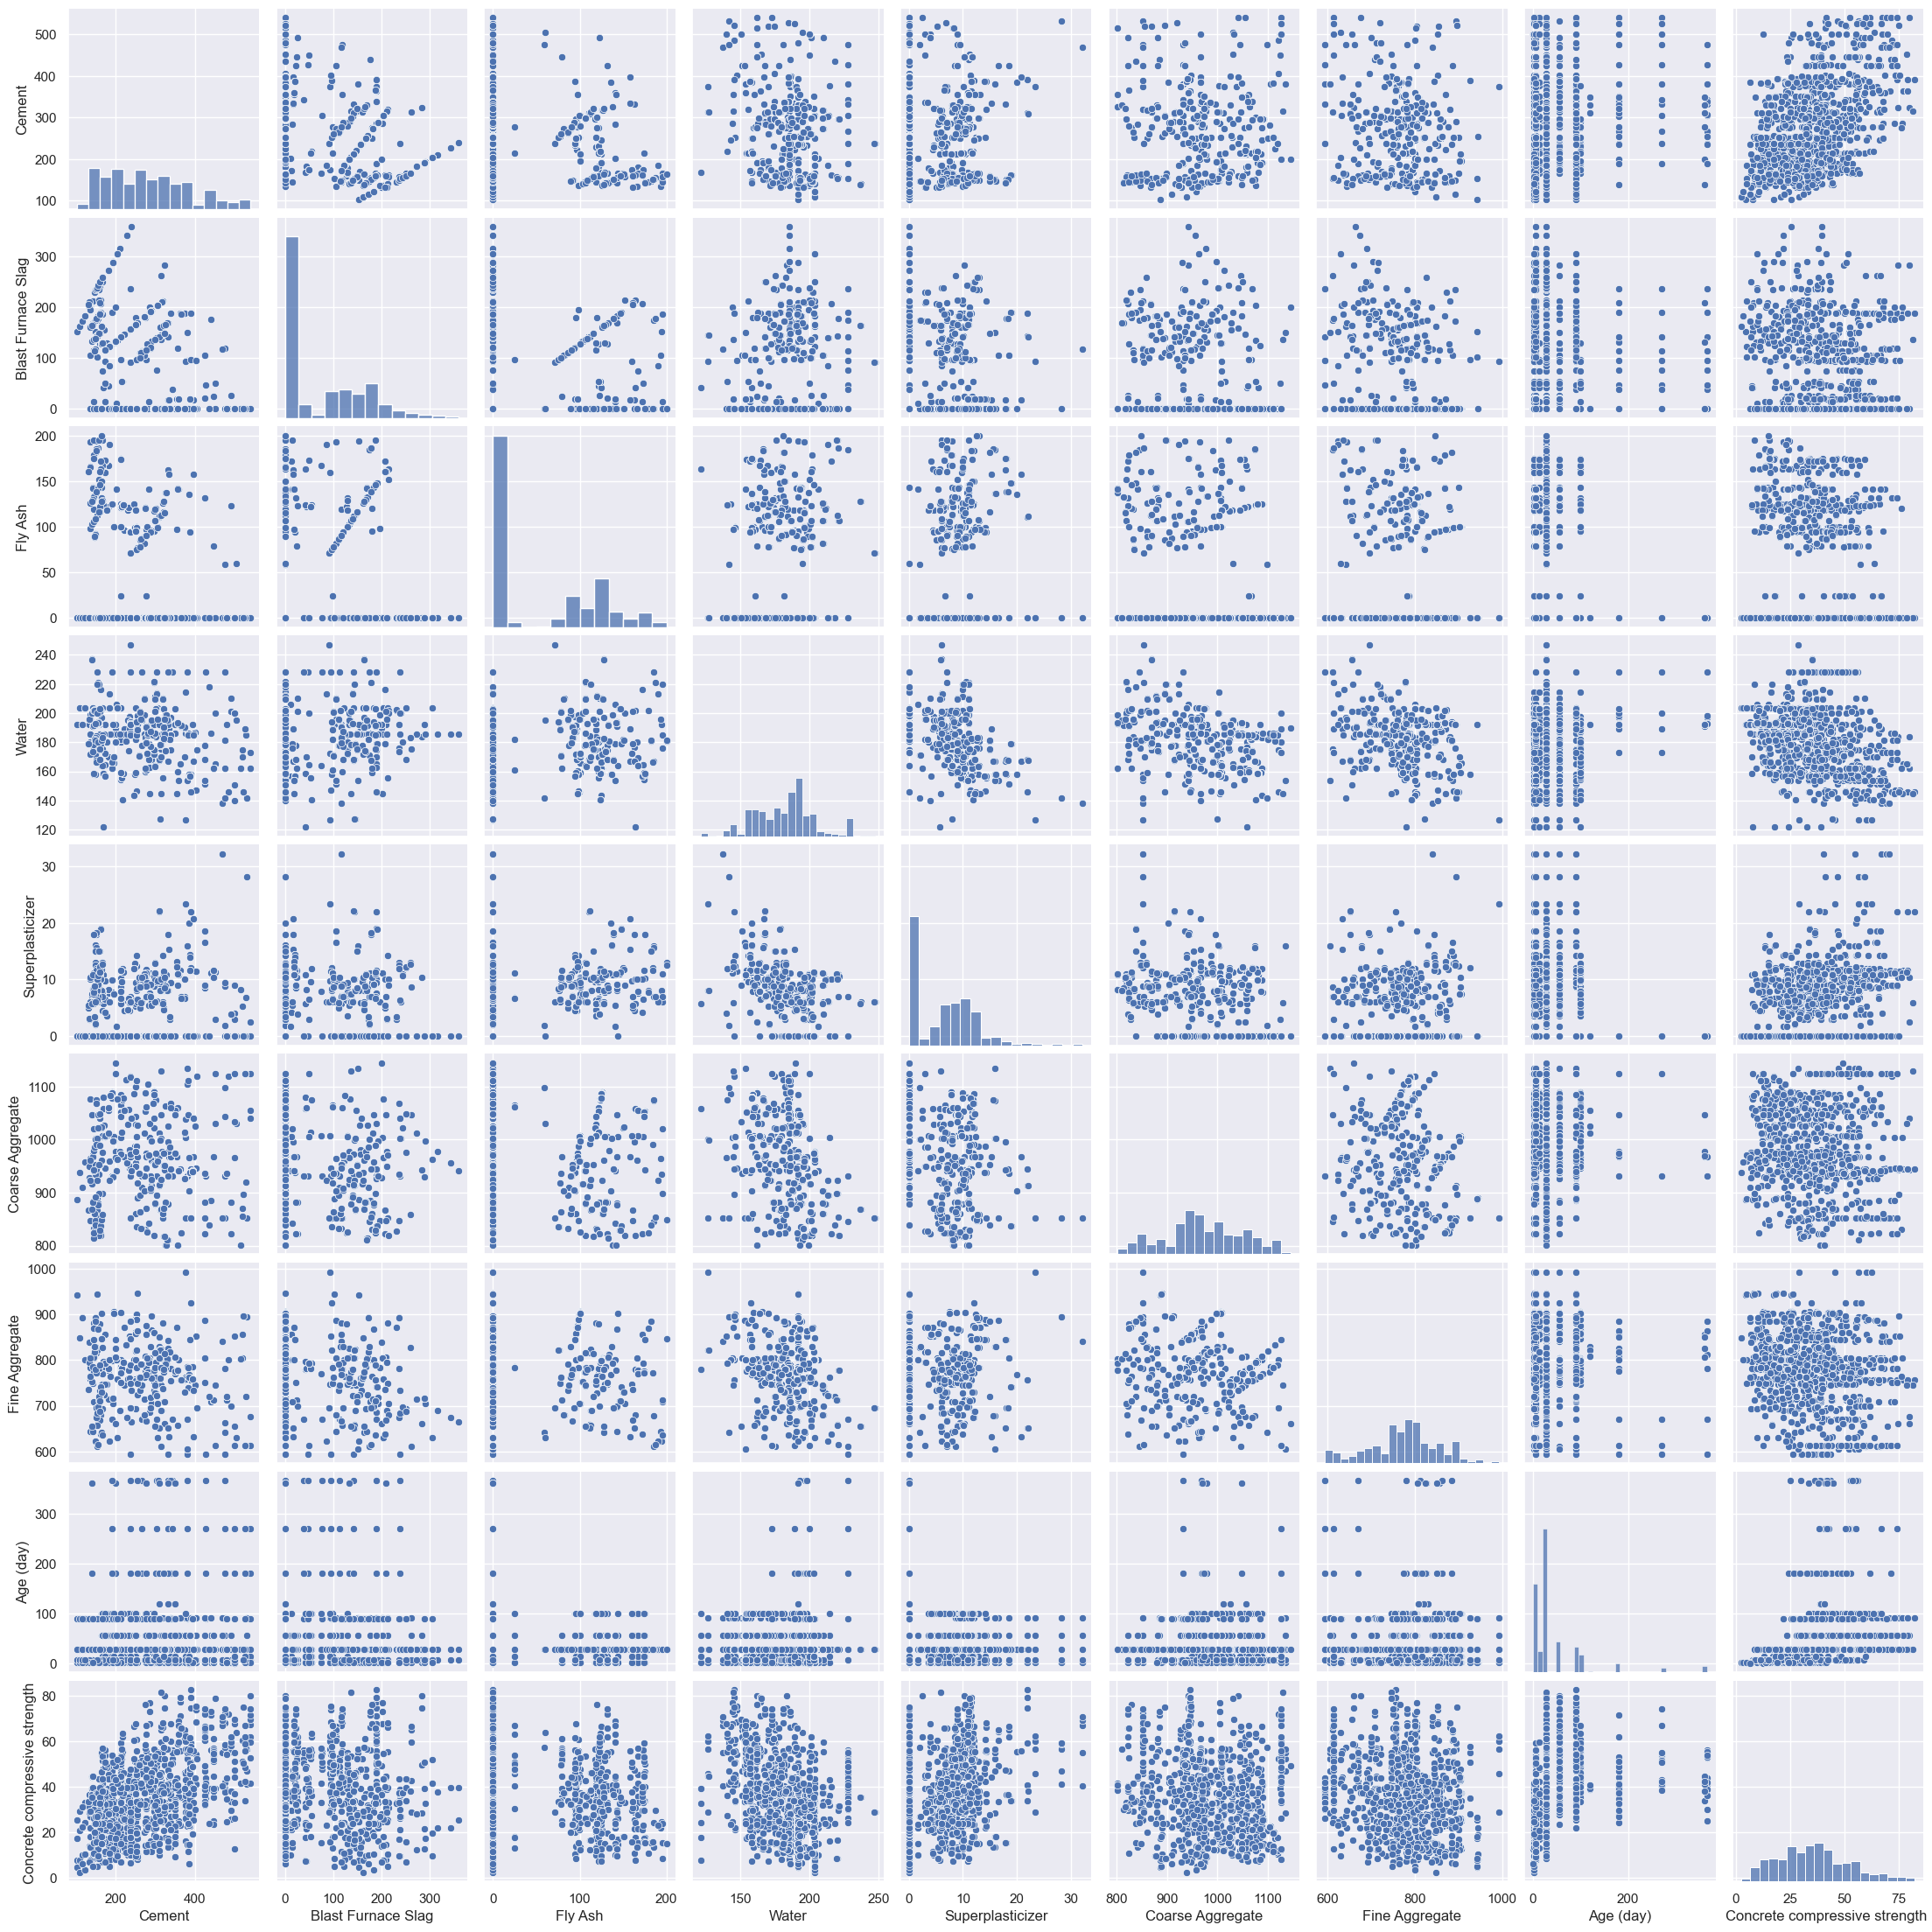

In [5]:
# scatter plot comparison between variables of the dataset

sns.pairplot(df)
#plt.savefig("my_seaborn_plot.png", dpi=300, bbox_inches="tight")
plt.show()

<Axes: >

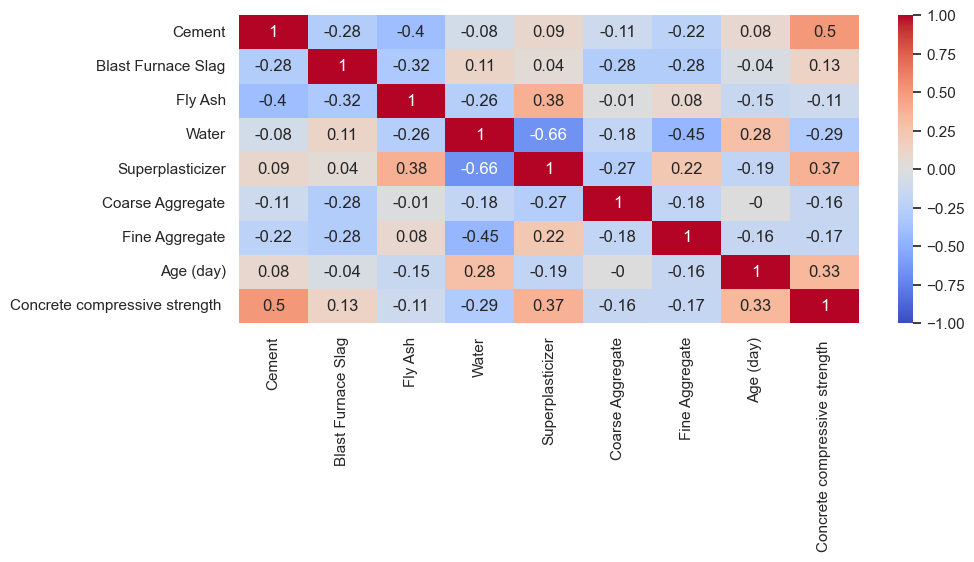

In [6]:
#correlation matrix
correlation = df.corr().round(2)

plt.figure(figsize=(10, 4))

# plt.savefig("correlation_plot.png", dpi=300, bbox_inches="tight")

#cmpa [vlag, seismic, coolwarm, viridis, mako, crest
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

In [7]:
#replace outliers (Data cleaning)
df.replace('?', -9999, inplace=True)

#split dataset
X = df.iloc[:, 0: -1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#SVR model 
model = RandomForestRegressor()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [8]:
#evaluating training and testing data

y_model_train = model.predict(X_train)
y_model_test = model.predict(X_test)

print(R2(y_train, y_model_train))
print(R2(y_test, y_model_test))

0.9868631997036553
0.8814581552766916


In [10]:
#trainned vs predicted
print(y_train[1], y_model_train[1])

61.88736576 62.64569480470004


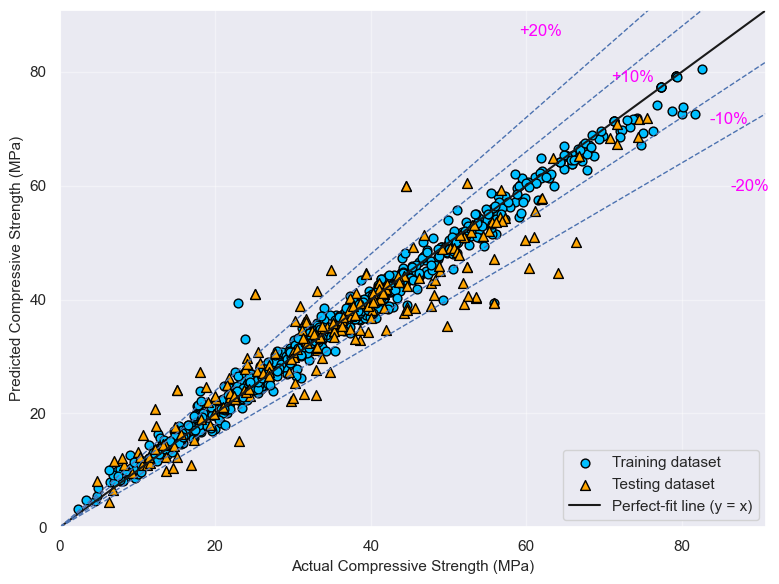

In [12]:
# model visualization

# ==========================
# INPUT YOUR DATA HERE
# ==========================

# Actual values
y_actual_train = y_train
y_actual_test = y_test

# Predicted values (reshaped)
y_pred_train = y_model_train
y_pred_test = y_model_test

# ==========================
# PLOT
# ==========================
plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(y_actual_train, y_pred_train,
            color='deepskyblue',
            edgecolor='black',
            s=40,
            label='Training dataset')

plt.scatter(y_actual_test, y_pred_test,
            color='orange',
            marker='^',
            edgecolor='black',
            s=50,
            label='Testing dataset')

# Axis limits
max_val = max(
    np.max(y_actual_train),
    np.max(y_actual_test),
    np.max(y_pred_train),
    np.max(y_pred_test)
) * 1.1

x = np.linspace(0, max_val, 100)

# Perfect fit line (y=x)
plt.plot(x, x, 'k-', linewidth=1.5, label='Perfect-fit line (y = x)')

# Error bands
plt.plot(x, 1.10*x, 'b--', linewidth=1)
plt.plot(x, 0.90*x, 'b--', linewidth=1)

plt.plot(x, 1.20*x, 'b--', linewidth=1)
plt.plot(x, 0.80*x, 'b--', linewidth=1)

# Labels for error bands
plt.text(max_val*0.78, max_val*0.86, '+10%', color='magenta')
plt.text(max_val*0.92, max_val*0.78, '-10%', color='magenta')

plt.text(max_val*0.65, max_val*0.95, '+20%', color='magenta')
plt.text(max_val*0.95, max_val*0.65, '-20%', color='magenta')

# Formatting
plt.xlabel('Actual Compressive Strength (MPa)', fontsize=11)
plt.ylabel('Predicted Compressive Strength (MPa)', fontsize=11)

# plt.title('Categorical Boosting Regression', fontsize=12)

plt.grid(True, linestyle='-', alpha=0.4)
plt.legend(loc='lower right')

plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.tight_layout()
plt.show()

In [15]:
#test by predicting new parameters

model.predict([[10.0, 30.0, 10.0,	120.0, 22.5,	10.0,	6.0, 28]])

C:\Users\user\Documents\Python Code\ML\Practice1\mlenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([20.00970358])

In [17]:
# Applying K-fold cross-validation and hyperparameter-tuning using GridSearchCV

#k-fold cross validation/ hyperparameter tunning
clf = GridSearchCV(model, {
    'n_estimators': [1, 5, 10, 15, 20 ],
    'random_state': [0, 30, 42]
}, cv=5, return_train_score=False)


# Fit the model using ONLY the training data
clf.fit(X_train, y_train)

#print results
# clf.cv_results_

#convert to df table format
clf_df = pd.DataFrame(clf.cv_results_)


#required columns
new_clf_df = clf_df[['rank_test_score', 'params', 'mean_test_score']]

new_clf_df

,rank_test_score,params,mean_test_score
0,13,"{'n_estimators': 1, 'random_state': 0}",0.782747
1,15,"{'n_estimators': 1, 'random_state': 30}",0.758398
2,14,"{'n_estimators': 1, 'random_state': 42}",0.775930
3,9,"{'n_estimators': 5, 'random_state': 0}",0.887461
4,12,"{'n_estimators': 5, 'random_state': 30}",0.874681
5,11,"{'n_estimators': 5, 'random_state': 42}",0.879386
6,6,"{'n_estimators': 10, 'random_state': 0}",0.899043
7,10,"{'n_estimators': 10, 'random_state': 30}",0.887345
8,8,"{'n_estimators': 10, 'random_state': 42}",0.896636
9,2,"{'n_estimators': 15, 'random_state': 0}",0.902925


In [20]:
print(clf.best_params_, clf.best_score_)

{'n_estimators': 20, 'random_state': 0} 0.9044590952761109
